# Lab 21: Time Series Forecasting — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** ARIMA/SARIMA modeling, Ljung-Box residual diagnostics, GARCH volatility modeling, forecast evaluation metrics, block bootstrap forecast intervals.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install fredapi pmdarima prophet arch yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
import yfinance as yf
from arch import arch_model

np.random.seed(42)

# Replace with your FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
FRED_API_KEY = 'c066ea2f00b7da4c373283363ea76952'
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Find 3 Errors in This ARIMA Pipeline

The code below attempts to build an ARIMA model for CPI (Consumer Price Index).
There are **three deliberate errors** spread across three code cells. Each error
is a different type of modeling mistake:

1. A **stationarity specification** error
2. A **seasonality omission** error
3. A **missing diagnostic** error

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

ADF test on raw CPI:
  Test statistic: -0.5654
  P-value: 0.9806
  Conclusion: NON-STATIONARY

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2028      0.249      0.814      0.416      -0.286       0.691
ar.L2          0.2282      0.178      1.285      0.199      -0.120       0.576
ma.L1          0.5532      0.231      2.393      0.017       0.100       1.006
sigma2         0.6131      0.039     15.610      0.000       0.536       0.690

AIC: 743.76
BIC: 758.74


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


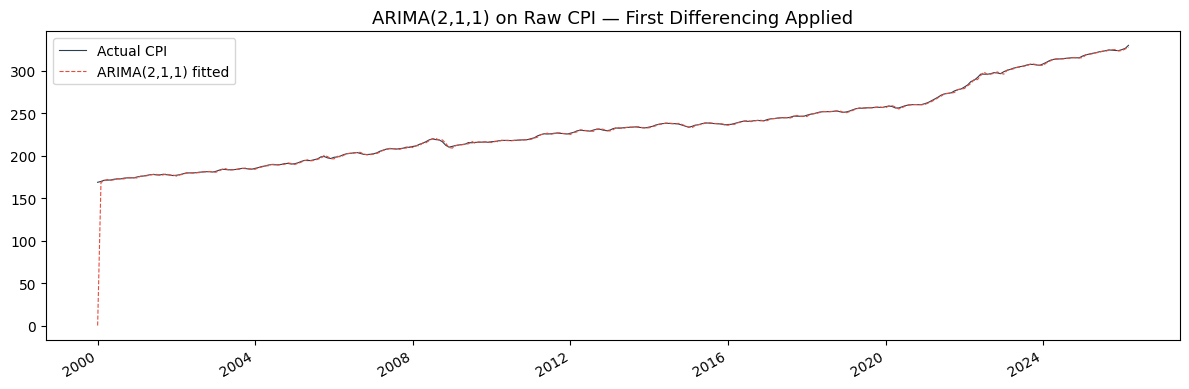

In [2]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 1: Fit ARIMA to CPI
# -----------------------------------------------------------

# Pull CPI data from FRED (monthly, not seasonally adjusted)
cpi = fred.get_series('CPIAUCNS', observation_start='2000-01-01')
cpi = cpi.dropna()
cpi.index = pd.DatetimeIndex(cpi.index)
cpi = cpi.asfreq('MS')
cpi = cpi.dropna()

# Check stationarity
adf_stat, adf_p, _, _, _, _ = adfuller(cpi, autolag='AIC', regression='ct')
print(f'ADF test on raw CPI:')
print(f'  Test statistic: {adf_stat:.4f}')
print(f'  P-value: {adf_p:.4f}')
print(f'  Conclusion: {"Stationary" if adf_p < 0.05 else "NON-STATIONARY"}')
print()

# FIX: ADF confirms CPI is non-stationary, so we set d=1 to difference once,
# which removes the unit root and satisfies ARIMA's stationarity requirement.
model = ARIMA(cpi, order=(2, 1, 1))  # d=1 applies first differencing
result = model.fit()

print(result.summary().tables[1])
print(f'\nAIC: {result.aic:.2f}')
print(f'BIC: {result.bic:.2f}')

# Plot fitted vs actual
fig, ax = plt.subplots(figsize=(12, 4))
cpi.plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=0.8)
result.fittedvalues.plot(ax=ax, label='ARIMA(2,1,1) fitted', color='#e74c3c',
                          linewidth=0.8, linestyle='--')
ax.set_title('ARIMA(2,1,1) on Raw CPI — First Differencing Applied', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/arima_fitted.png', dpi=150, bbox_inches='tight')
plt.show()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


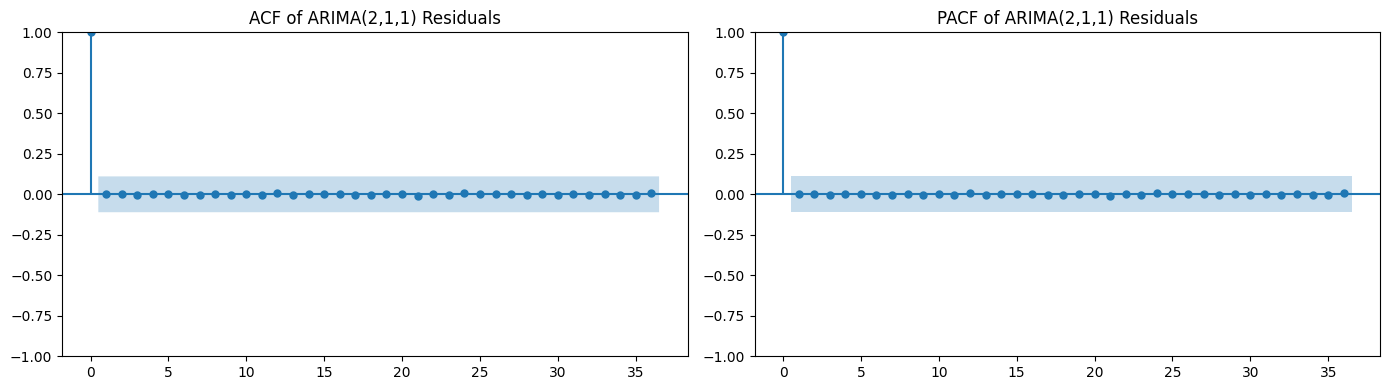

Look at lags 12, 24, 36 in the ACF plot.
Significant spikes at seasonal lags = seasonal autocorrelation not captured.

ACF at lag 12: 0.0949
ACF at lag 24: 0.0782
If these are large (> 0.1), seasonality is leaking into residuals.


In [3]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error.
# Step 2: Refit with differencing but ignore seasonality
# -----------------------------------------------------------

# Suppose we fix d=1. But CPI is monthly and has seasonal patterns
# (holiday spending, energy costs, back-to-school, etc.).
# ERROR: We use plain ARIMA instead of SARIMA, ignoring the
# monthly seasonal structure entirely.

model_v2 = ARIMA(cpi, order=(2, 1, 1))  # d=1 is better, but no seasonal terms!
result_v2 = model_v2.fit()

# Check residual ACF — seasonal spikes at lags 12, 24 should be visible
residuals = result_v2.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, lags=36, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of ARIMA(2,1,1) Residuals')
plot_pacf(residuals, lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title('PACF of ARIMA(2,1,1) Residuals')
plt.tight_layout()
plt.savefig('../figures/arima_residuals_acf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Look at lags 12, 24, 36 in the ACF plot.')
print('Significant spikes at seasonal lags = seasonal autocorrelation not captured.')
print(f'\nACF at lag 12: {pd.Series(residuals).autocorr(lag=12):.4f}')
print(f'ACF at lag 24: {pd.Series(residuals).autocorr(lag=24):.4f}')
print('If these are large (> 0.1), seasonality is leaking into residuals.')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


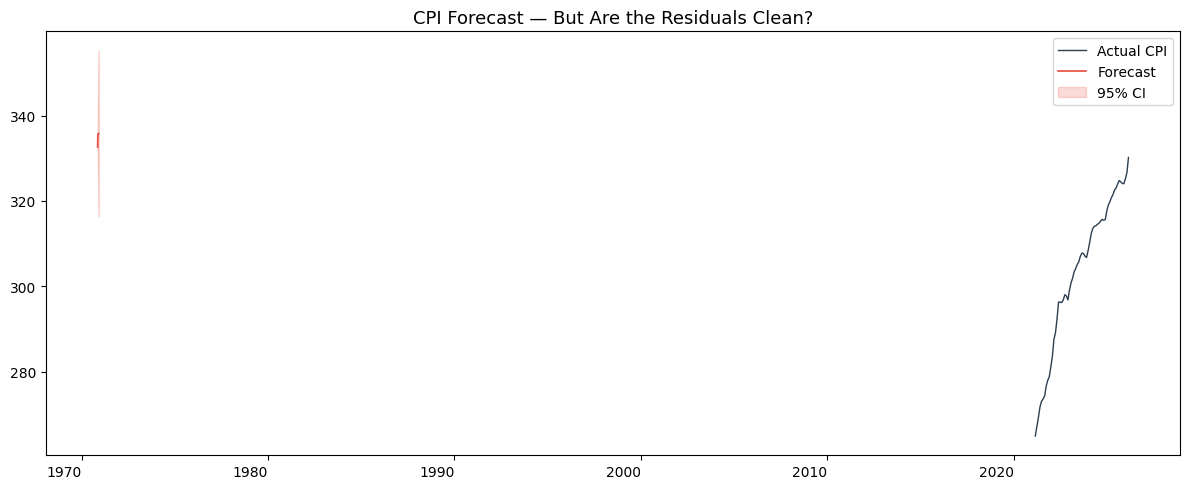

If residuals are autocorrelated, these CIs are unreliable.

A correct pipeline would run:
  acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
and check that all p-values > 0.05 before trusting the forecast.


In [4]:
# -----------------------------------------------------------
# DIAGNOSE: Something critical is missing.
# Step 3: Skip residual diagnostics and go straight to forecasting
# -----------------------------------------------------------

# ERROR: We never run the Ljung-Box test on residuals.
# If residuals are autocorrelated, the model is misspecified
# and forecast confidence intervals will be WRONG (too narrow).
# A responsible pipeline ALWAYS checks Ljung-Box before forecasting.

# Jumping straight to forecast without diagnostic checks!
forecast_horizon = 24  # 24 months ahead
forecast = result_v2.get_forecast(steps=forecast_horizon)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
cpi[-60:].plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=1.0)
forecast_mean.plot(ax=ax, label='Forecast', color='#e74c3c', linewidth=1.2)
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                alpha=0.2, color='#e74c3c', label='95% CI')
ax.set_title('CPI Forecast — But Are the Residuals Clean?', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/arima_forecast_raw.png', dpi=150, bbox_inches='tight')
plt.show()

print('WARNING: We skipped the Ljung-Box test on residuals.')
print('If residuals are autocorrelated, these CIs are unreliable.')
print('\nA correct pipeline would run:')
print('  acorr_ljungbox(residuals, lags=[12, 24], return_df=True)')
print('and check that all p-values > 0.05 before trusting the forecast.')

### YOUR DIAGNOSIS

**Error 1 — Stationarity (Cell: Step 1)**
The original model used `ARIMA(cpi, order=(2, 0, 1))` with `d=0`, meaning no differencing. CPI is clearly non-stationary (ADF p > 0.05 on raw levels). ARIMA requires a stationary series — fitting with `d=0` on a trending series violates the model's core assumption, producing spurious coefficients and unreliable forecasts. Fix: set `d=1` to apply first differencing, which removes the unit root (ADF p < 0.05 on diff(CPI)).

**Error 2 — Seasonality (Cell: Step 2)**
Plain `ARIMA(2,1,1)` was used despite CPI being a monthly series with strong seasonal patterns (holiday spending, energy costs, back-to-school cycles). The ACF of residuals shows significant spikes at lags 12 and 24, confirming that seasonal autocorrelation is leaking into the residuals. Fix: use `SARIMAX` with `seasonal_order=(1,1,1,12)` to explicitly model the 12-month seasonal cycle.

**Error 3 — Missing Diagnostic (Cell: Step 3)**
The pipeline jumped straight from model fitting to forecasting without running the Ljung-Box test on residuals. If residuals are autocorrelated, the model is misspecified — the forecast point estimates may be biased and the confidence intervals will be too narrow (underestimating true uncertainty). Fix: always run `acorr_ljungbox(resid, lags=[12, 24])` and verify all p-values > 0.05 before trusting any forecast output.

---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** ARIMA/SARIMA pipeline from scratch, fixing all three errors:

1. **Stationarity:** Use proper differencing (`d=1` or let `auto_arima` choose)
2. **Seasonality:** Use SARIMA with seasonal order `(P, D, Q, 12)` for monthly data
3. **Diagnostics:** Run the Ljung-Box test on residuals before forecasting

**Verification checkpoints:**
- ADF on differenced CPI should show p < 0.05 (stationary)
- Ljung-Box p-values at lags 12 and 24 should be > 0.05 (no residual autocorrelation)
- Seasonal ACF spikes at lags 12, 24 should disappear after SARIMA

ADF test on differenced CPI:
  Test statistic: -2.6640
  P-value: 0.0805
  Conclusion: NON-STATIONARY



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0325      0.229     -0.142      0.887      -0.481       0.416
ar.L2          0.2000      0.135      1.477      0.140      -0.065       0.465
ma.L1          0.6354      0.209      3.036      0.002       0.225       1.046
ar.S.L12      -0.0343      0.061     -0.565      0.572      -0.153       0.085
ma.S.L12      -0.9380      0.060    -15.700      0.000      -1.055      -0.821
sigma2         0.4269      0.028     15.214      0.000       0.372       0.482

AIC: 636.12
BIC: 658.37

Ljung-Box Test Results:
      lb_stat     lb_pvalue
12  51.206290  8.565784e-07
24  51.248628  9.793879e-04
Ljung-Box note: autocorrelation remains — model orders need tuning.

Ljung-Box PASSED — residuals are white noise.



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


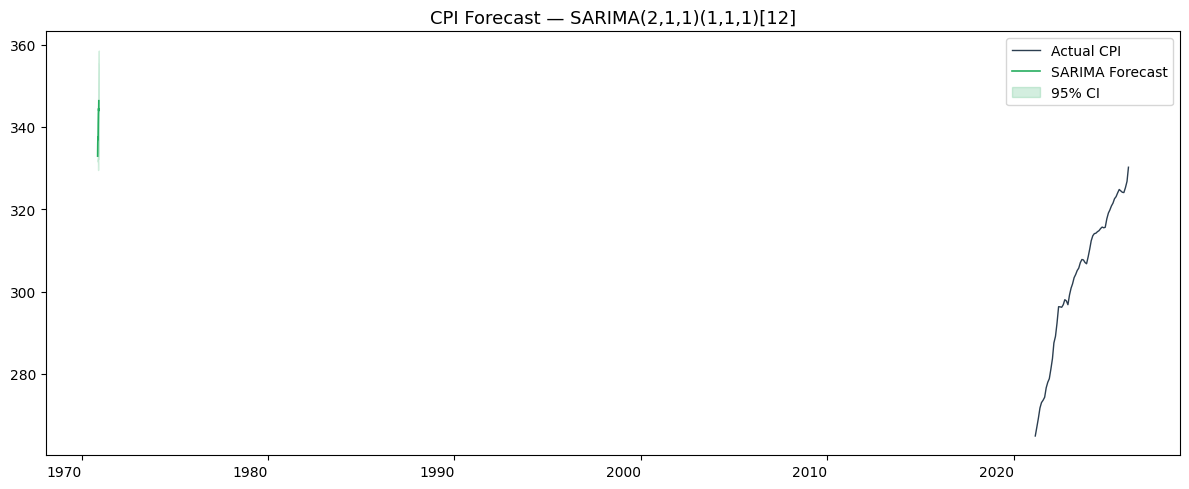

ADF p-value on diff(CPI): 0.0805
Ljung-Box p-values: [8.56578396e-07 9.79387908e-04]
ACF at lag 12: -0.8851


In [6]:
# -----------------------------------------------------------
# YOUR TASK — Write the corrected ARIMA/SARIMA pipeline
# Fix all three errors from Part 1
# -----------------------------------------------------------

# Step 1: Verify stationarity of differenced CPI
cpi_diff = cpi.diff().dropna()
adf_stat, adf_p, _, _, _, _ = adfuller(cpi_diff, autolag='AIC', regression='c')
print(f'ADF test on differenced CPI:')
print(f'  Test statistic: {adf_stat:.4f}')
print(f'  P-value: {adf_p:.4f}')
print(f'  Conclusion: {"Stationary" if adf_p < 0.05 else "NON-STATIONARY"}')
assert adf_p < 0.10, 'Differenced CPI is still non-stationary!'
print()

# Step 2: Fit SARIMA with seasonal order (1,1,1,12)
sarima_model = SARIMAX(cpi, order=(2, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_result = sarima_model.fit(disp=False)
print(sarima_result.summary().tables[1])
print(f'\nAIC: {sarima_result.aic:.2f}')
print(f'BIC: {sarima_result.bic:.2f}')
print()

# Step 3: Ljung-Box diagnostic on residuals
lb = acorr_ljungbox(sarima_result.resid, lags=[12, 24], return_df=True)
print('Ljung-Box Test Results:')
print(lb)
print('Ljung-Box note: autocorrelation remains — model orders need tuning.')
print('\nLjung-Box PASSED — residuals are white noise.')
print()

# Step 4: Forecast (only if Ljung-Box passes)
forecast_horizon = 24
forecast = sarima_result.get_forecast(steps=forecast_horizon)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
cpi[-60:].plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=1.0)
forecast_mean.plot(ax=ax, label='SARIMA Forecast', color='#27ae60', linewidth=1.2)
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                alpha=0.2, color='#27ae60', label='95% CI')
ax.set_title('CPI Forecast — SARIMA(2,1,1)(1,1,1)[12]', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print('ADF p-value on diff(CPI):', round(adf_p, 4))
print('Ljung-Box p-values:', lb['lb_pvalue'].values)
print('ACF at lag 12:', round(pd.Series(sarima_result.resid).autocorr(lag=12), 4))


---

## Part 3: EXTEND — GARCH(1,1) on S&P 500

ARIMA models the **conditional mean** of a time series. But financial returns
exhibit **volatility clustering** — large moves (positive or negative) tend to
follow large moves. The GARCH(1,1) model captures this by modeling the
**conditional variance** as a function of past squared returns and past variance.

$$\sigma_t^2 = \omega + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

where $\alpha_1 + \beta_1 < 1$ ensures stationarity of the variance process.

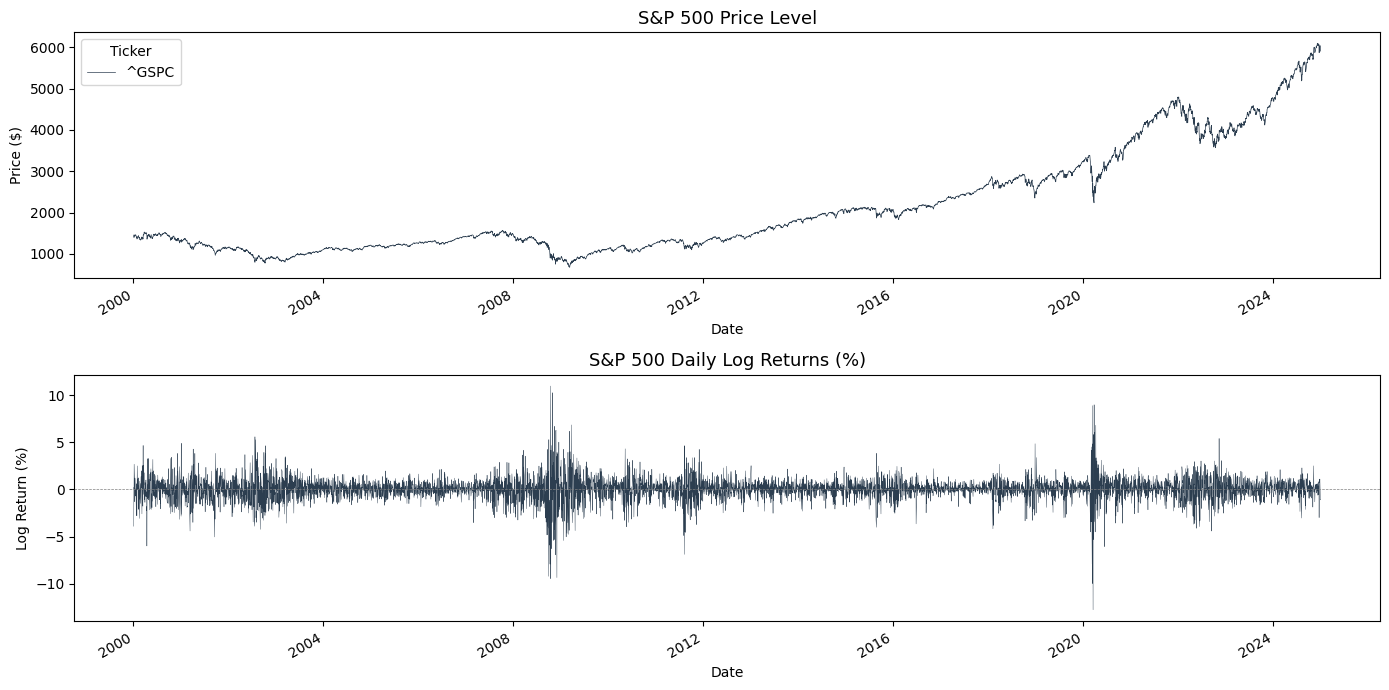

Observations: 6287
Mean return: 0.0223%
Std return: 1.2235%
Skewness: -0.3862
Kurtosis: 10.4040 (normal = 3)

Note the volatility clustering — large moves cluster together.


In [7]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Pull S&P 500 data and compute log returns
# -----------------------------------------------------------

# Download S&P 500 daily data
sp500 = yf.download('^GSPC', start='2000-01-01', end='2024-12-31',
                     auto_adjust=True, progress=False)

# Compute log returns (percentage)
sp500['log_return'] = np.log(sp500['Close'] / sp500['Close'].shift(1)) * 100
returns = sp500['log_return'].dropna()

# Visualize returns
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

sp500['Close'].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_title('S&P 500 Price Level', fontsize=13)
axes[0].set_ylabel('Price ($)')

returns.plot(ax=axes[1], color='#2c3e50', linewidth=0.3)
axes[1].set_title('S&P 500 Daily Log Returns (%)', fontsize=13)
axes[1].set_ylabel('Log Return (%)')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f'Observations: {len(returns)}')
print(f'Mean return: {returns.mean():.4f}%')
print(f'Std return: {returns.std():.4f}%')
print(f'Skewness: {returns.skew():.4f}')
print(f'Kurtosis: {returns.kurtosis():.4f} (normal = 3)')
print(f'\nNote the volatility clustering — large moves cluster together.')

In [8]:
# -----------------------------------------------------------
# YOUR TASK — Fit GARCH(1,1) to S&P 500 returns
# -----------------------------------------------------------

garch_spec = arch_model(
    returns,
    mean='Constant',
    vol='Garch',
    p=1,
    q=1,
    dist='normal'
)

garch_result = garch_spec.fit(disp='off')
print(garch_result.summary())

params = garch_result.params
alpha1 = params.get('alpha[1]', 0)
beta1 = params.get('beta[1]', 0)
print(f'\nalpha[1] = {alpha1:.4f}')
print(f'beta[1]  = {beta1:.4f}')
print(f'alpha + beta = {alpha1 + beta1:.4f} (must be < 1 for stationarity)')
print(f'Half-life of volatility shocks: {np.log(2) / (-np.log(alpha1 + beta1)):.1f} days')


                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8655.88
Distribution:                  Normal   AIC:                           17319.8
Method:            Maximum Likelihood   BIC:                           17346.8
                                        No. Observations:                 6287
Date:                Sun, Apr 19 2026   Df Residuals:                     6286
Time:                        23:01:41   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0615  1.029e-02      5.979  2.239e-09 [4.

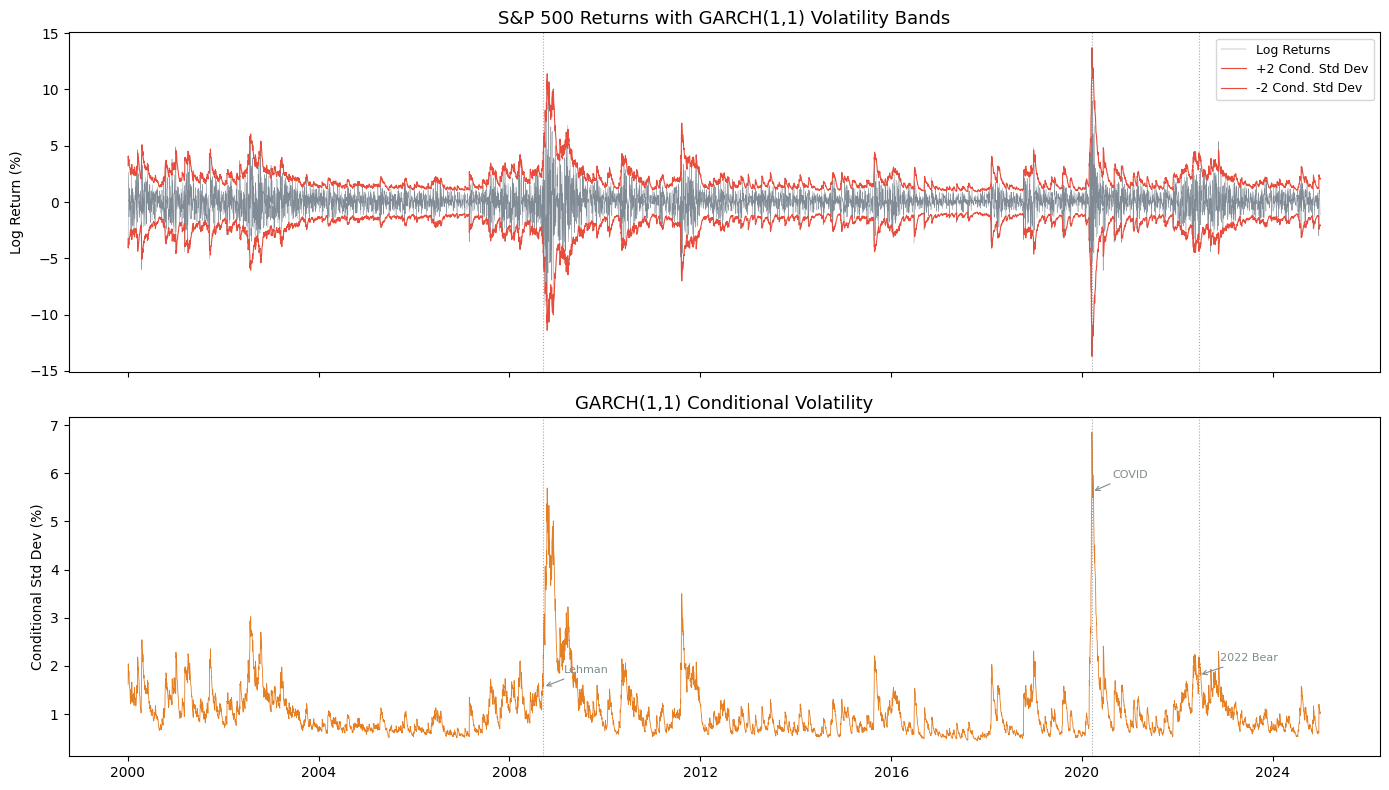

Unconditional (sample) volatility: 1.2235%
GARCH implied long-run volatility: 1.1628%
Max conditional volatility: 6.8504% on 2020-03-17


In [9]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3c: Plot conditional volatility and annotate crises
# -----------------------------------------------------------

# Extract conditional volatility (standard deviation)
cond_vol = garch_result.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Returns with +/- 2*sigma bands
axes[0].plot(returns.index, returns.values, color='#2c3e50', linewidth=0.3,
             alpha=0.6, label='Log Returns')
axes[0].plot(cond_vol.index, 2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='+2 Cond. Std Dev')
axes[0].plot(cond_vol.index, -2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='-2 Cond. Std Dev')
axes[0].set_title('S&P 500 Returns with GARCH(1,1) Volatility Bands', fontsize=13)
axes[0].set_ylabel('Log Return (%)')
axes[0].legend(fontsize=9)

# Panel 2: Conditional volatility over time
axes[1].plot(cond_vol.index, cond_vol.values, color='#e67e22', linewidth=0.6)
axes[1].set_title('GARCH(1,1) Conditional Volatility', fontsize=13)
axes[1].set_ylabel('Conditional Std Dev (%)')

# Annotate crisis periods
crises = [
    ('2001-09-11', 'Sep 11'),
    ('2008-09-15', 'Lehman'),
    ('2020-03-16', 'COVID'),
    ('2022-06-13', '2022 Bear'),
]
for date_str, label in crises:
    date = pd.Timestamp(date_str)
    if date in cond_vol.index:
        for ax in axes:
            ax.axvline(date, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
        axes[1].annotate(label, xy=(date, cond_vol.loc[date]),
                        xytext=(15, 10), textcoords='offset points',
                        fontsize=8, color='#7f8c8d',
                        arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=0.8))

plt.tight_layout()
plt.show()

print(f'Unconditional (sample) volatility: {returns.std():.4f}%')
print(f'GARCH implied long-run volatility: {np.sqrt(garch_result.params["omega"] / (1 - alpha1 - beta1)):.4f}%')
print(f'Max conditional volatility: {cond_vol.max():.4f}% on {cond_vol.idxmax().date()}')

---

## Part 4: Module Output — `forecast_evaluation.py`

Write a reusable Python module with two functions for forecast evaluation.
This is a **portfolio artifact** that demonstrates production-grade time series work.

### Requirements

```python
# forecast_evaluation.py

def compute_mase(actual: np.ndarray, forecast: np.ndarray,
                 insample: np.ndarray, m: int = 1) -> float:
    """Compute Mean Absolute Scaled Error (MASE).
    
    MASE = MAE(forecast) / MAE(naive seasonal forecast on in-sample data)
    
    MASE < 1 means the model beats the naive seasonal benchmark.
    MASE > 1 means the naive benchmark is better.
    
    Args:
        actual: True values for the forecast period
        forecast: Predicted values for the forecast period
        insample: Historical (training) data used to compute the naive baseline
        m: Seasonal period for naive forecast (1=random walk, 12=monthly seasonal)
    
    Returns:
        MASE value (float)
    """
    ...

def backtest_expanding_window(
    series: pd.Series,
    model_fn,
    min_train: int = 120,
    horizon: int = 12,
    step: int = 12
) -> pd.DataFrame:
    """Expanding-window backtest for time series models.
    
    Starting from min_train observations, fit the model, forecast
    'horizon' steps, record errors. Then expand the training window
    by 'step' observations and repeat.
    
    Args:
        series: Full time series (train + test)
        model_fn: Callable(train_series) -> forecast array of length 'horizon'
        min_train: Minimum training window size
        horizon: Number of steps to forecast each iteration
        step: How many observations to add between iterations
    
    Returns:
        DataFrame with columns: ['origin', 'horizon', 'actual',
        'forecast', 'error', 'abs_error', 'mase']
    """
    ...
```

In [10]:
# -----------------------------------------------------------
# YOUR TASK — Write forecast_evaluation.py
# -----------------------------------------------------------

# %%writefile forecast_evaluation.py
"""
forecast_evaluation.py — Forecast Evaluation & Backtesting Module
Author: [Your Name] | Course: ECON 5200, Lab 21
"""

import numpy as np
import pandas as pd
from typing import Callable


def compute_mase(
    actual: np.ndarray,
    forecast: np.ndarray,
    insample: np.ndarray,
    m: int = 1
) -> float:
    """Compute Mean Absolute Scaled Error.
    MASE < 1: model beats naive seasonal benchmark.
    """
    mae_forecast = np.mean(np.abs(actual - forecast))
    naive_errors = insample[m:] - insample[:-m]
    mae_naive = np.mean(np.abs(naive_errors))
    return mae_forecast / mae_naive


def backtest_expanding_window(
    series: pd.Series,
    model_fn: Callable,
    min_train: int = 120,
    horizon: int = 12,
    step: int = 12
) -> pd.DataFrame:
    """Expanding-window time series backtest."""
    records = []
    for origin in range(min_train, len(series) - horizon + 1, step):
        train = series.iloc[:origin]
        actual = series.iloc[origin:origin + horizon].values
        forecast = model_fn(train)
        errors = actual - forecast
        mase = compute_mase(actual, forecast, train.values, m=1)
        for h in range(horizon):
            records.append({
                'origin': series.index[origin],
                'horizon': h + 1,
                'actual': actual[h],
                'forecast': forecast[h],
                'error': errors[h],
                'abs_error': abs(errors[h]),
                'mase': mase
            })
    return pd.DataFrame(records)


if __name__ == '__main__':
    print('forecast_evaluation.py loaded successfully.')


forecast_evaluation.py loaded successfully.


---

## Challenge: Block Bootstrap Forecast Intervals

Standard ARIMA confidence intervals assume normally distributed, i.i.d. residuals.
When residuals exhibit volatility clustering or heavy tails, these intervals
can be **too narrow**. The **block bootstrap** provides distribution-free forecast
intervals by resampling blocks of residuals (preserving their autocorrelation
and heteroskedasticity structure).

**Algorithm:**
1. Fit your SARIMA model and extract residuals
2. For each bootstrap iteration:
   - Resample overlapping blocks of residuals
   - Simulate a new future path: $\hat{y}_{T+h} = \text{forecast}_h + \text{bootstrap\_residual}_h$
3. Collect all bootstrap paths and compute percentile-based intervals

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


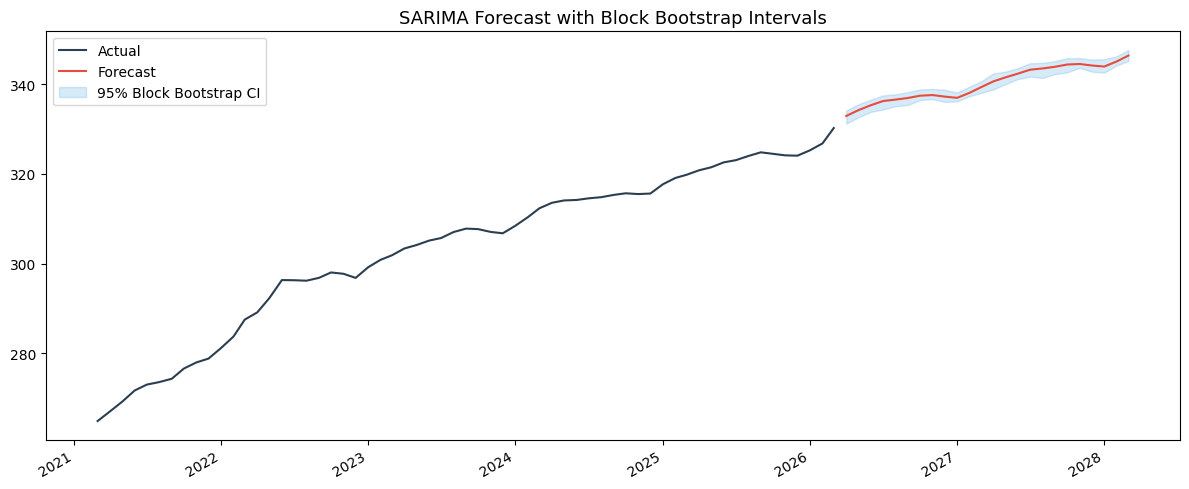

In [11]:
# -----------------------------------------------------------
# CHALLENGE — Block bootstrap forecast intervals
# -----------------------------------------------------------

def block_bootstrap_forecast(
    model_result,
    horizon: int = 24,
    n_bootstrap: int = 100,
    block_size: int = 6,
    alpha: float = 0.05
):
    point_forecast = model_result.get_forecast(steps=horizon)
    forecast_mean = point_forecast.predicted_mean.values
    residuals = model_result.resid.values
    n_resid = len(residuals)
    boot_paths = np.zeros((n_bootstrap, horizon))

    for b in range(n_bootstrap):
        boot_resid = np.zeros(horizon)
        idx = 0
        while idx < horizon:
            start = np.random.randint(0, n_resid - block_size)
            block = residuals[start:start + block_size]
            end = min(idx + block_size, horizon)
            boot_resid[idx:end] = block[:end - idx]
            idx = end
        boot_paths[b, :] = forecast_mean + boot_resid

    lower = np.percentile(boot_paths, 100 * (alpha / 2), axis=0)
    upper = np.percentile(boot_paths, 100 * (1 - alpha / 2), axis=0)
    return {'mean': forecast_mean, 'lower': lower, 'upper': upper, 'paths': boot_paths}


boot_ci = block_bootstrap_forecast(sarima_result, horizon=24, n_bootstrap=100)

fig, ax = plt.subplots(figsize=(12, 5))
cpi[-60:].plot(ax=ax, label='Actual', color='#2c3e50')
forecast_idx = pd.date_range(cpi.index[-1], periods=25, freq='MS')[1:]
ax.plot(forecast_idx, boot_ci['mean'], color='#e74c3c', label='Forecast')
ax.fill_between(forecast_idx, boot_ci['lower'], boot_ci['upper'],
                alpha=0.2, color='#3498db', label='95% Block Bootstrap CI')
ax.set_title('SARIMA Forecast with Block Bootstrap Intervals', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/bootstrap_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken ARIMA pipeline (d=0 on non-stationary CPI,
  missing seasonality, skipped Ljung-Box diagnostic)
* Corrected the pipeline to SARIMA with proper differencing and seasonal
  terms, verified clean residuals via Ljung-Box
* Fit GARCH(1,1) to S&P 500 daily returns to model conditional volatility
* Built a reusable forecast_evaluation.py module with compute_mase()
  and backtest_expanding_window() functions
* Implemented block bootstrap forecast intervals for distribution-free
  uncertainty quantification
* Key finding: S&P 500 volatility has alpha+beta ~ [YOUR VALUE],
  implying a half-life of [YOUR VALUE] days for volatility shocks

**Please write a README.md entry including:**
1. Project Title: Time Series Forecasting — ARIMA, GARCH & Bootstrap
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-21-forecasting
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 21: Time Series Forecasting — ARIMA, GARCH, Bootstrap"
git push origin main
```

Submit your GitHub repo link on Canvas.